# Author

### Importing necessary libraries

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Model, load_model, Sequential

from pathlib import Path
import PIL
import os

### Reading Input from local Machine


In [21]:
glaucoma = Path(r"D:\Learning\eye disease prediction\dataset\glaucoma")
cataract = Path(r"D:\Learning\eye disease prediction\dataset\cataract")
normal = Path(r"D:\Learning\eye disease prediction\dataset\normal")
diabetic_retinopathy = Path(r"D:\Learning\eye disease prediction\dataset\diabetic_retinopathy")

### Creating a dataframe with the file path and the labels


In [22]:
disease_type = [glaucoma, cataract,normal,diabetic_retinopathy]
df = pd.DataFrame()
from tqdm import tqdm
for types in disease_type:
    for imagepath in tqdm(list(types.iterdir()), desc= str(types)):
        df = pd.concat([df, pd.DataFrame({'image': [str(imagepath)],'disease_type': [disease_type.index(types)]})], ignore_index=True)

D:\Learning\eye disease prediction\dataset\glaucoma: 100%|███████████████████████| 1007/1007 [00:00<00:00, 1635.85it/s]
D:\Learning\eye disease prediction\dataset\cataract: 100%|███████████████████████| 1038/1038 [00:00<00:00, 1631.91it/s]
D:\Learning\eye disease prediction\dataset\normal: 100%|█████████████████████████| 1074/1074 [00:00<00:00, 1801.07it/s]
D:\Learning\eye disease prediction\dataset\diabetic_retinopathy: 100%|███████████| 1098/1098 [00:00<00:00, 1780.71it/s]


In [23]:
df

,image,disease_type
0,D:\Learning\eye disease prediction\dataset\gla...,0
1,D:\Learning\eye disease prediction\dataset\gla...,0
2,D:\Learning\eye disease prediction\dataset\gla...,0
3,D:\Learning\eye disease prediction\dataset\gla...,0
4,D:\Learning\eye disease prediction\dataset\gla...,0
...,...,...
4212,D:\Learning\eye disease prediction\dataset\dia...,3
4213,D:\Learning\eye disease prediction\dataset\dia...,3
4214,D:\Learning\eye disease prediction\dataset\dia...,3
4215,D:\Learning\eye disease prediction\dataset\dia...,3


In [24]:
df.disease_type.value_counts()

disease_type
3    1098
2    1074
1    1038
0    1007
Name: count, dtype: int64

### Defining function to plot sample images

In [25]:
def plot_image(n, num_samples=3):
    disease_labels = ['glaucoma', 'cataract', 'normal', 'diabetic_retinopathy']
    images = df[df['disease_type'] == n].sample(num_samples)['image']

    plt.figure(figsize=(12, 12))

    for i, path in enumerate(images, 1):
        img = (plt.imread(path) - plt.imread(path).min()) / plt.imread(path).max()
        plt.subplot(3, 3, i)
        plt.imshow(img)
        plt.axis('off')
        plt.title(disease_labels[n])

    plt.show()

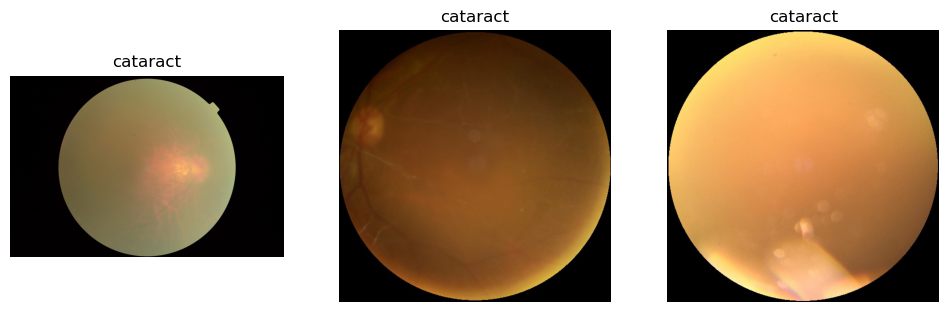

In [26]:
plot_image(1)

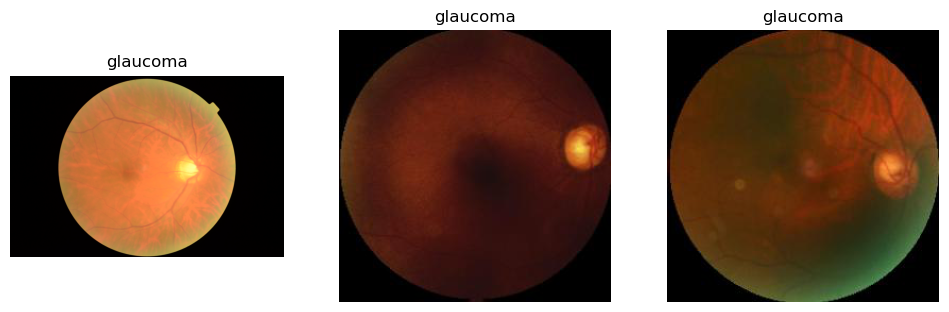

In [27]:
plot_image(0)

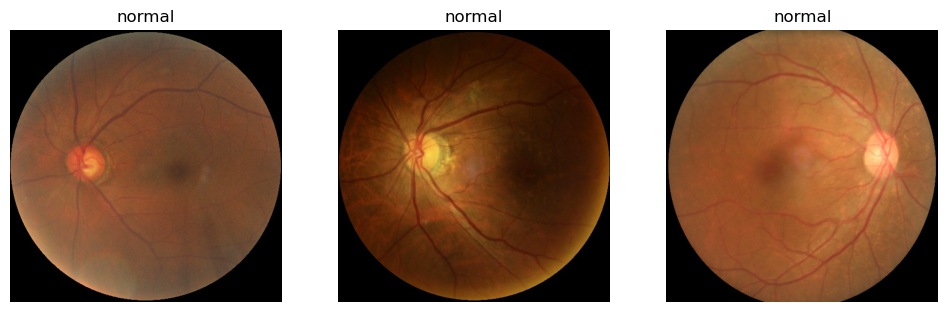

In [28]:
plot_image(2)

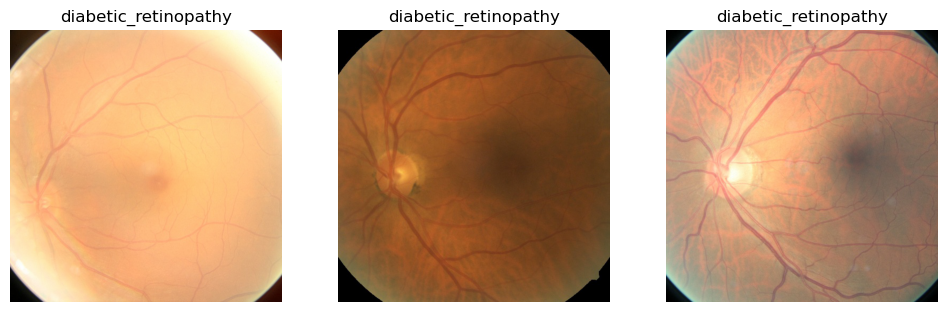

In [29]:
plot_image(3)

### Mapping the labels to the type of eye disease

In [30]:
df['disease_type'] = df['disease_type'].map({0:'glaucoma',1:'cataract',2:'normal',3:'diabetic_retinopathy'})

### Checking the label count to verify if it has been mapped

In [31]:
df.disease_type.value_counts()

disease_type
diabetic_retinopathy    1098
normal                  1074
cataract                1038
glaucoma                1007
Name: count, dtype: int64

### Randomising the dataset

In [32]:
df1 = df.sample(frac=1).reset_index(drop=True)

### Creating a countplot of the disease type

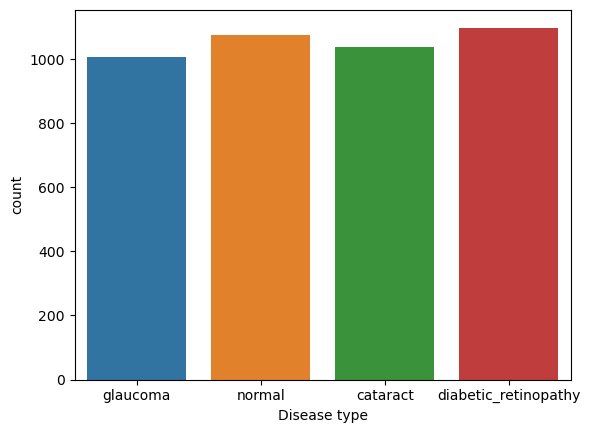

In [33]:
sns.countplot(x = 'disease_type', data = df1)
plt.xlabel("Disease type")
plt.show()

### Importing tensorflow libraries

In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

### Augumentating the images

In [35]:
datagen = ImageDataGenerator(preprocessing_function=preprocess_input,validation_split=0.2)

### Creating the train data

In [36]:
train_data = datagen.flow_from_dataframe(dataframe=df1,
                                          x_col ='image',
                                          y_col = 'disease_type',
                                          target_size=(224,224),
                                          class_mode = 'categorical',
                                          batch_size = 32,
                                          shuffle = True,
                                          subset = 'training')

Found 3374 validated image filenames belonging to 4 classes.


### Creating the validation data

In [37]:
valid_data = datagen.flow_from_dataframe(dataframe=df1,
                                          x_col ='image',
                                          y_col = 'disease_type',
                                          target_size=(224,224),
                                          class_mode = 'categorical',
                                          batch_size = 32,
                                          shuffle = False,
                                          subset = 'validation')

Found 843 validated image filenames belonging to 4 classes.


In [38]:
labels=[key for key in train_data.class_indices]
num_classes = len(disease_type)

In [39]:
num_classes, labels

(4, ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal'])

In [40]:
model = keras.Sequential([ 
    layers.Rescaling(1./255, input_shape=(224,224, 3)), 
    layers.Conv2D(16, 3, padding='same', activation='relu'), 
    layers.MaxPooling2D(), 
    layers.Conv2D(32, 3, padding='same', activation='relu'), 
    layers.MaxPooling2D(), 
    layers.Conv2D(64, 3, padding='same', activation='relu'), 
    layers.MaxPooling2D(), 
    layers.Flatten(), 
    layers.Dense(128, activation='relu'), 
    layers.Dense(num_classes,activation='softmax') 
]) 

In [41]:
model.compile(optimizer='adam', 
              loss=tf.keras.losses.categorical_crossentropy, 
              metrics=['accuracy']) 
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 224, 224, 16)      448       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 112, 112, 16)     0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 112, 112, 32)      4640      
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 56, 56, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 56, 56, 64)        1

### Fitting the model

In [26]:
his = model.fit( 
  train_data,
  validation_data=valid_data, 
  epochs=15 
)

Epoch 1/15
106/106 [==============================] - 91s 841ms/step - loss: 0.8886 - accuracy: 0.6126 - val_loss: 0.6377 - val_accuracy: 0.7153
Epoch 2/15
106/106 [==============================] - 88s 824ms/step - loss: 0.5915 - accuracy: 0.7540 - val_loss: 0.5212 - val_accuracy: 0.7900
Epoch 3/15
106/106 [==============================] - 83s 780ms/step - loss: 0.4625 - accuracy: 0.8112 - val_loss: 0.5280 - val_accuracy: 0.7746
Epoch 4/15
106/106 [==============================] - 82s 772ms/step - loss: 0.4100 - accuracy: 0.8260 - val_loss: 0.4331 - val_accuracy: 0.8316
Epoch 5/15
106/106 [==============================] - 83s 781ms/step - loss: 0.3368 - accuracy: 0.8610 - val_loss: 0.4086 - val_accuracy: 0.8493
Epoch 6/15
106/106 [==============================] - 82s 770ms/step - loss: 0.3230 - accuracy: 0.8711 - val_loss: 0.4072 - val_accuracy: 0.8446
Epoch 7/15
106/106 [==============================] - 81s 765ms/step - loss: 0.2863 - accuracy: 0.8809 - val_loss: 0.4069 - val_ac

### Creating a plot of accuracy and val_acuracy for each epoch

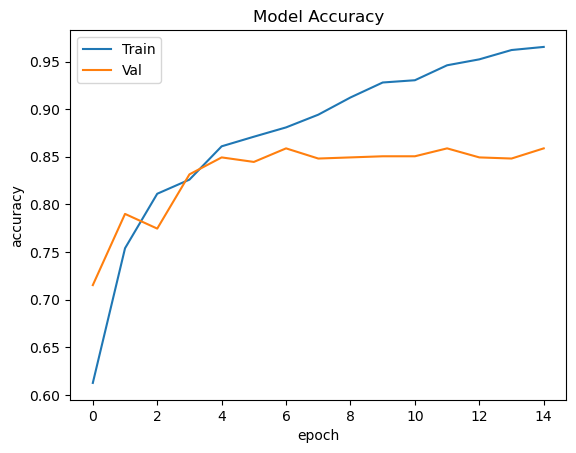

In [27]:
plt.plot(his.history['accuracy'])
plt.plot(his.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Val'])
plt.show()

### Creating a plot of loss and validation loss for each epoch

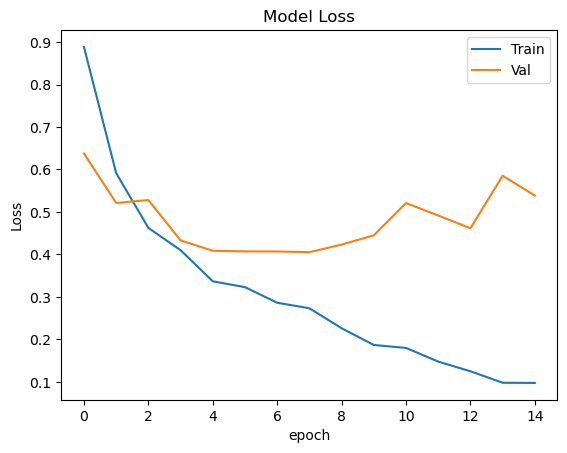

In [28]:
plt.plot(his.history['loss'])
plt.plot(his.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Val'])
plt.show()

### Evaluating the model

In [29]:
y_test = valid_data.classes
y_pred = model.predict(valid_data)
y_pred = np.argmax(y_pred,axis=1)

27/27 [==============================] - 10s 373ms/step


### Generating classification report

In [30]:
print(classification_report(y_test,y_pred,target_names = labels))

                      precision    recall  f1-score   support

            cataract       0.85      0.90      0.88       209
diabetic_retinopathy       0.99      0.98      0.99       239
            glaucoma       0.73      0.79      0.76       191
              normal       0.84      0.74      0.79       204

            accuracy                           0.86       843
           macro avg       0.85      0.85      0.85       843
        weighted avg       0.86      0.86      0.86       843



### Saving the model

In [31]:
model.save("cnnkeras.h5")

In [42]:
def load_model():
    model=tf.keras.models.load_model('cnnkeras.h5')
    return model

In [43]:
def import_and_predict(image_data, model):

        model=tf.keras.models.load_model('cnnkeras.h5')
        size = (224,224)    
        image = ImageOps.fit(image_data, size, Image.Resampling.LANCZOS)
        image = np.asarray(image)
        img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        #img_resize = (cv2.resize(img, dsize=(75, 75),interpolation=cv2.INTER_CUBIC))/255.
        
        img_reshape = img[np.newaxis,...]
    
        prediction = model.predict(img_reshape)
        
        return prediction

In [44]:
import cv2
from PIL import Image, ImageOps
import numpy as np

image = Image.open('test 1C.jpg')
predictions = import_and_predict(image, model)
score = tf.nn.softmax(predictions[0])
print(predictions)
print(score)
print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(labels[np.argmax(score)], 100 * np.max(score))
)

1/1 [==============================] - 0s 219ms/step
[[9.99999404e-01 9.89216886e-08 4.46696191e-07 1.36404585e-14]]
tf.Tensor([0.4753667  0.17487776 0.17487781 0.17487775], shape=(4,), dtype=float32)
This image most likely belongs to cataract with a 47.54 percent confidence.


In [45]:
image = Image.open('test 2N.jpg')
predictions = import_and_predict(image, model)
score = tf.nn.softmax(predictions[0])
print(predictions)
print(score)
print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(labels[np.argmax(score)], 100 * np.max(score))
)

1/1 [==============================] - 0s 140ms/step
[[9.9426538e-01 2.7525595e-03 2.9821347e-03 1.0700449e-08]]
tf.Tensor([0.4734601  0.17566079 0.17570114 0.17517795], shape=(4,), dtype=float32)
This image most likely belongs to cataract with a 47.35 percent confidence.


In [46]:
image = Image.open('test 3g.jpg')
predictions = import_and_predict(image, model)
score = tf.nn.softmax(predictions[0])
print(predictions)
print(score)
print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(labels[np.argmax(score)], 100 * np.max(score))
)

1/1 [==============================] - 0s 156ms/step
[[3.3362772e-04 9.9966311e-01 3.2287924e-06 2.1288749e-10]]
tf.Tensor([0.17495377 0.4752549  0.17489599 0.17489542], shape=(4,), dtype=float32)
This image most likely belongs to diabetic_retinopathy with a 47.53 percent confidence.


In [47]:
image = Image.open('test_4D.jpg')
predictions = import_and_predict(image, model)
score = tf.nn.softmax(predictions[0])
print(predictions)
print(score)
print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(labels[np.argmax(score)], 100 * np.max(score))
)

FileNotFoundError: [Errno 2] No such file or directory: 'test_4D.jpg'

In [48]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 224, 224, 16)      448       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 112, 112, 16)     0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 112, 112, 32)      4640      
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 56, 56, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 56, 56, 64)        1